# Calculo de Eigenvalores para un modelo de BTC (Boundary Time Crystals) https://arxiv.org/abs/1708.05014
 Importamos librerias importantes, principalmente qutip que ya nos hace la vectorización para el Liouvilliano y para definir los operadores e incluso para realizar los productos tensoriales de manera sencilla

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

In [4]:

vec1= basis(5,2) 
up = basis(2,0) # (1,0)
down = basis(2,1) # (0,1)

upx = (basis(2,0) + basis(2,1)).unit() # Initial state “The system is initialised in the pure state with all spins aligned along the x-direction…”

Probando como hacer matrices de densidad y trazas parciales usando las funciones de qutip

In [5]:
# Matriz de densidad para 2 espines

psi = (1/np.sqrt(2))*(1/np.sqrt(2))*(tensor(up,down) - tensor(down,up)) 

rho = psi * psi.dag()

rho_0 = rho.ptrace(0) # Tr_1 rho
rho_1 = rho.ptrace(1)

## Queremos obtener los eigenvalores del Liouvilliano
En general y en la función de qutip 

$$\mathcal{L}[\rho] = i[\rho, H] + \left( L\rho L^{\dagger} - \frac{1}{2} \{L^{\dagger}L, \rho\} \right) = \lambda \rho$$

En el modelo usan el siguiente Hamiltoniano

$$H = \omega_0 \sum_j \sigma^x_j$$
En el paper usan la siguiente expresión ya simplificada

$$\mathcal{L}[\rho] = i\omega_0[\rho, S^x] + \frac{\kappa}{S}\left( S_{-}\rho S_{+} - \frac{1}{2} \{S_{+}S_{-}, \rho\} \right)$$


In [2]:
import numpy as np
from qutip import *
# Graphs
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Para guardar los datos
import os


In [3]:
def build_system(Nb, omega_0):
    """
    Nb: No. de espines en la frontera, S = Nb/2
    omega_0: frecuencia del Hamiltoniano
    """
    S = Nb / 2
    Sx = jmat(S, 'x')
    H = omega_0 * Sx
    return H
"""------------------------------------------------------------------------------------"""
def build_operators(Nb, kappa):
    """
    Construye, para un Nb y kappa dados, los operadores de espín,
    el operador de salto (disipación) y los operadores de valor esperado.
    """
    S = Nb / 2
    Sx, Sy, Sz = jmat(S, 'x'), jmat(S, 'y'), jmat(S, 'z')
    Sm = np.sqrt(kappa / S) * jmat(S, '-')

    jump_ops = [Sm]
    exp_ops = [Sx, Sy, Sz]

    return jump_ops, exp_ops, S
"""------------------------------------------------------------------------------------"""
def do_spectrum(Nb, omega_0, jump_ops):
    H = build_system(Nb, omega_0)

    L = liouvillian(H, jump_ops)
    eigs = L.eigenenergies()

    return eigs
"""------------------------------------------------------------------------------------"""
def simulation(Nb, omega_0, init_rho, t, jump_ops, exp_ops):
    H = build_system(Nb, omega_0)

    evo = mesolve(H, init_rho, t, jump_ops, e_ops=exp_ops)
    return evo


results = {}
eigenvalues = {}


# Guardado de datos 

In [4]:
"""
Sistema de guardado con checkpointing por combinación de parámetros
(Nb, kappa, omega_0), para poder calcular varias "fases" del sistema
sin perder avance si el cómputo se interrumpe a medias.
"""

import time

RESULTS_DIR = 'btc_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

def get_file_paths(Nb, kappa, omega_0):
    """Nombres de archivo (SIN forzar extensión .qu) para una combinación dada"""
    tag = f'Nb_{Nb}_k_{kappa}_w0_{omega_0}'
    eigen_file = os.path.join(RESULTS_DIR, f'btc_eigenvalues_{tag}.npz')
    sim_file_base = os.path.join(RESULTS_DIR, f'btc_simulation_{tag}')
    return eigen_file, sim_file_base

def load_results_complete(Nb, kappa, omega_0):
    """Carga eigenvalores y simulación para una sola combinación, si existen"""
    eigen_file, sim_file_base = get_file_paths(Nb, kappa, omega_0)
    sim_file = sim_file_base + '.qu'

    eigs = None
    if os.path.exists(eigen_file):
        data = np.load(eigen_file)
        eigs = data['eigenvalues']

    evo = None
    if os.path.exists(sim_file):
        try:
            evo = qload(sim_file_base)
        except Exception as e:
            print(f"✗ Error cargando simulación para Nb={Nb}, kappa={kappa}, omega_0={omega_0}: {e}")

    return eigs, evo

def compute_phase_diagram(param_list, force_recompute=False):
    """
    param_list: lista de tuplas (Nb, kappa, omega_0).
    Por cada combinación: si ya está guardada la carga; si no, la calcula
    y la guarda de inmediato (checkpoint) antes de seguir con la siguiente,
    para no perder avance si el cómputo se interrumpe.
    """
    results = {}
    eigenvalues = {}

    for (Nb, kappa, omega_0) in param_list:
        key = (Nb, kappa, omega_0)
        print(f"\n{'='*50}")
        print(f"Procesando Nb={Nb}, kappa={kappa}, omega_0={omega_0}")

        eigen_file, sim_file_base = get_file_paths(Nb, kappa, omega_0)
        sim_file = sim_file_base + '.qu'

        eigen_exists = os.path.exists(eigen_file) and os.path.getsize(eigen_file) > 0
        sim_exists = os.path.exists(sim_file) and os.path.getsize(sim_file) > 0

        if eigen_exists and sim_exists and not force_recompute:
            print("✓ Cargando resultados existentes")
            eigs, evo = load_results_complete(Nb, kappa, omega_0)
            if eigs is not None and evo is not None:
                eigenvalues[key] = eigs
                results[key] = evo
                continue
            else:
                print(" Los archivos existen pero no se pudieron cargar, recalculando...")

        print("Calculando...")
        jump_ops, exp_ops, S = build_operators(Nb, kappa)
        psi_x = spin_coherent(S, np.pi/2, 0)
        rho0x = psi_x * psi_x.dag()
        t = np.linspace(0, 60, 200)

        eigs = do_spectrum(Nb, omega_0, jump_ops)
        evo = simulation(Nb, omega_0, rho0x, t, jump_ops, exp_ops)

        eigenvalues[key] = eigs
        results[key] = evo

        # ---- Checkpoint: guardar de inmediato ----
        np.savez_compressed(eigen_file,
                             eigenvalues=eigs,
                             Nb=Nb, kappa=kappa, omega_0=omega_0,
                             S=S, timestamp=time.time())
        qsave(evo, sim_file_base)

        if os.path.exists(eigen_file) and os.path.exists(sim_file):
            print(f" Guardado exitosamente para {key}")
        else:
            print(f" FALLÓ EL GUARDADO para {key}")

    return results, eigenvalues

def load_all_results(param_list):
    """Solo carga (sin calcular) todas las combinaciones ya guardadas"""
    results = {}
    eigenvalues = {}
    for (Nb, kappa, omega_0) in param_list:
        key = (Nb, kappa, omega_0)
        eigs, evo = load_results_complete(Nb, kappa, omega_0)
        if eigs is not None:
            eigenvalues[key] = eigs
        if evo is not None:
            results[key] = evo
    return results, eigenvalues

# ------------------------- Fases a calcular -------------------------
Nb_list = [20, 40, 80, 100, 120]
kappa_list = [1.0]      # agrega más valores para explorar otras fases, p.ej. [0.5, 1.0, 2.0]
omega_0_list = [0.5 ,0 ,1.5]   # idem, p.ej. [1.0, 1.5, 2.0]

param_list = [(Nb, kappa, omega_0)
              for Nb in Nb_list
              for kappa in kappa_list
              for omega_0 in omega_0_list]


## Diagnostico de los resultados

In [5]:
print("="*70)
print("DIAGNÓSTICO DEL SISTEMA DE GUARDADO")
print("="*70)

print(f"\nCarpeta de resultados: {os.path.abspath(RESULTS_DIR)}")

if os.path.exists(RESULTS_DIR):
    files = sorted(os.listdir(RESULTS_DIR))
    if files:
        print(f"\nArchivos en '{RESULTS_DIR}':")
        for f in files:
            size = os.path.getsize(os.path.join(RESULTS_DIR, f))
            print(f"   {f:55} {size:10} bytes")
    else:
        print(f"\nNo hay archivos todavía en '{RESULTS_DIR}'")
else:
    print(f"\nLa carpeta '{RESULTS_DIR}' no existe todavía")

print(f"\nCombinaciones definidas en param_list: {len(param_list)}")
for (Nb, kappa, omega_0) in param_list:
    eigen_file, sim_file_base = get_file_paths(Nb, kappa, omega_0)
    sim_file = sim_file_base + '.qu'
    eigen_ok = ' :)' if os.path.exists(eigen_file) else 'X'
    sim_ok = ' :)' if os.path.exists(sim_file) else 'X'
    print(f"   Nb={Nb:>4}  kappa={kappa}  omega_0={omega_0}   eigen:{eigen_ok}  sim:{sim_ok}")


DIAGNÓSTICO DEL SISTEMA DE GUARDADO

Carpeta de resultados: F:\Tareas_Proyectos\PythonProjects\QMPhysics\BoundaryTimeCrystal\btc_results

Archivos en 'btc_results':
   .ipynb_checkpoints                                               0 bytes
   btc_eigenvalues_Nb_100_k_1.0_w0_0.5.npz                     151755 bytes
   btc_eigenvalues_Nb_100_k_1.0_w0_0.npz                         5697 bytes
   btc_eigenvalues_Nb_100_k_1.0_w0_1.5.npz                     134323 bytes
   btc_eigenvalues_Nb_120_k_1.0_w0_0.5.npz                     215525 bytes
   btc_eigenvalues_Nb_120_k_1.0_w0_1.5.npz                     199536 bytes
   btc_eigenvalues_Nb_20_k_1.0_w0_0.5.npz                        6452 bytes
   btc_eigenvalues_Nb_20_k_1.0_w0_0.npz                          1416 bytes
   btc_eigenvalues_Nb_20_k_1.0_w0_1.5.npz                        5459 bytes
   btc_eigenvalues_Nb_40_k_1.0_w0_0.5.npz                       24802 bytes
   btc_eigenvalues_Nb_40_k_1.0_w0_0.npz                          1992 bytes

# Carga de los datos 
Este bloque se carga los resultados de la simulacion del sistema tambien define los eigenvalores y estados evolucionados y los valores esperados de los exp.ops

In [6]:
print("\n" + "="*50)
print("CARGANDO RESULTADOS")
print("="*50)

results, eigenvalues = load_all_results(param_list)

print(f"\n✅ Eigenvalores disponibles para {len(eigenvalues)} combinaciones: {sorted(eigenvalues.keys())}")
print(f"✅ Simulaciones disponibles para {len(results)} combinaciones: {sorted(results.keys())}")

# Para calcular las combinaciones que falten (o todas, la primera vez):
results, eigenvalues = compute_phase_diagram(param_list)

# Para forzar el recálculo de todo (aunque ya exista en disco):
# results, eigenvalues = compute_phase_diagram(param_list, force_recompute=True)

# Para recalcular solo una combinación puntual:
# results_single, eigenvalues_single = compute_phase_diagram([(120, 1.0, 1.5)], force_recompute=True)



CARGANDO RESULTADOS

✅ Eigenvalores disponibles para 14 combinaciones: [(20, 1.0, 0), (20, 1.0, 0.5), (20, 1.0, 1.5), (40, 1.0, 0), (40, 1.0, 0.5), (40, 1.0, 1.5), (80, 1.0, 0), (80, 1.0, 0.5), (80, 1.0, 1.5), (100, 1.0, 0), (100, 1.0, 0.5), (100, 1.0, 1.5), (120, 1.0, 0.5), (120, 1.0, 1.5)]
✅ Simulaciones disponibles para 14 combinaciones: [(20, 1.0, 0), (20, 1.0, 0.5), (20, 1.0, 1.5), (40, 1.0, 0), (40, 1.0, 0.5), (40, 1.0, 1.5), (80, 1.0, 0), (80, 1.0, 0.5), (80, 1.0, 1.5), (100, 1.0, 0), (100, 1.0, 0.5), (100, 1.0, 1.5), (120, 1.0, 0.5), (120, 1.0, 1.5)]

Procesando Nb=20, kappa=1.0, omega_0=0.5
✓ Cargando resultados existentes

Procesando Nb=20, kappa=1.0, omega_0=0
✓ Cargando resultados existentes

Procesando Nb=20, kappa=1.0, omega_0=1.5
✓ Cargando resultados existentes

Procesando Nb=40, kappa=1.0, omega_0=0.5
✓ Cargando resultados existentes

Procesando Nb=40, kappa=1.0, omega_0=0
✓ Cargando resultados existentes

Procesando Nb=40, kappa=1.0, omega_0=1.5
✓ Cargando resultados

In [12]:
eigenvalues.items()

dict_items([((20, 1.0, 0.5), array([-1.51879643e+01-1.29424424e+01j, -1.51879643e+01+1.29424424e+01j,
       -1.46586445e+01+1.22108344e+01j, -1.46586445e+01-1.22108344e+01j,
       -1.42330754e+01+1.19798952e+01j, -1.42330754e+01-1.19798952e+01j,
       -1.41518080e+01+1.14905360e+01j, -1.41518080e+01-1.14905360e+01j,
       -1.37112055e+01-1.12598885e+01j, -1.37112055e+01+1.12598885e+01j,
       -1.36683175e+01+1.07811489e+01j, -1.36683175e+01-1.07811489e+01j,
       -1.33016220e+01-1.10357354e+01j, -1.33016220e+01+1.10357354e+01j,
       -1.32114648e+01-1.05527198e+01j, -1.32114648e+01+1.05527198e+01j,
       -1.32089414e+01-1.00820579e+01j, -1.32089414e+01+1.00820579e+01j,
       -1.27868627e+01+1.03281382e+01j, -1.27868627e+01-1.03281382e+01j,
       -1.27742317e+01+9.39248203e+00j, -1.27742317e+01-9.39248203e+00j,
       -1.27351552e+01+9.85831318e+00j, -1.27351552e+01-9.85831318e+00j,
       -1.23935766e+01+1.01107066e+01j, -1.23935766e+01-1.01107066e+01j,
       -1.23644474e+01

# Sistema de spin

C:\Users\Arturo\AppData\Local\Temp\ipykernel_21232\1922633425.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


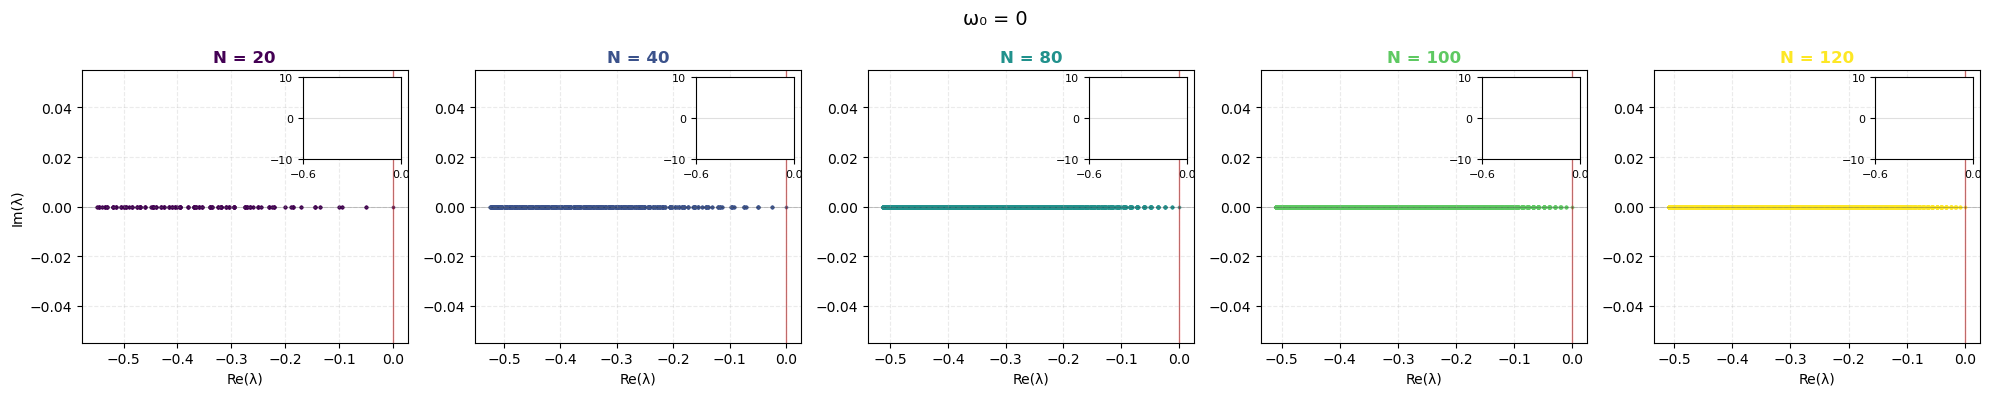

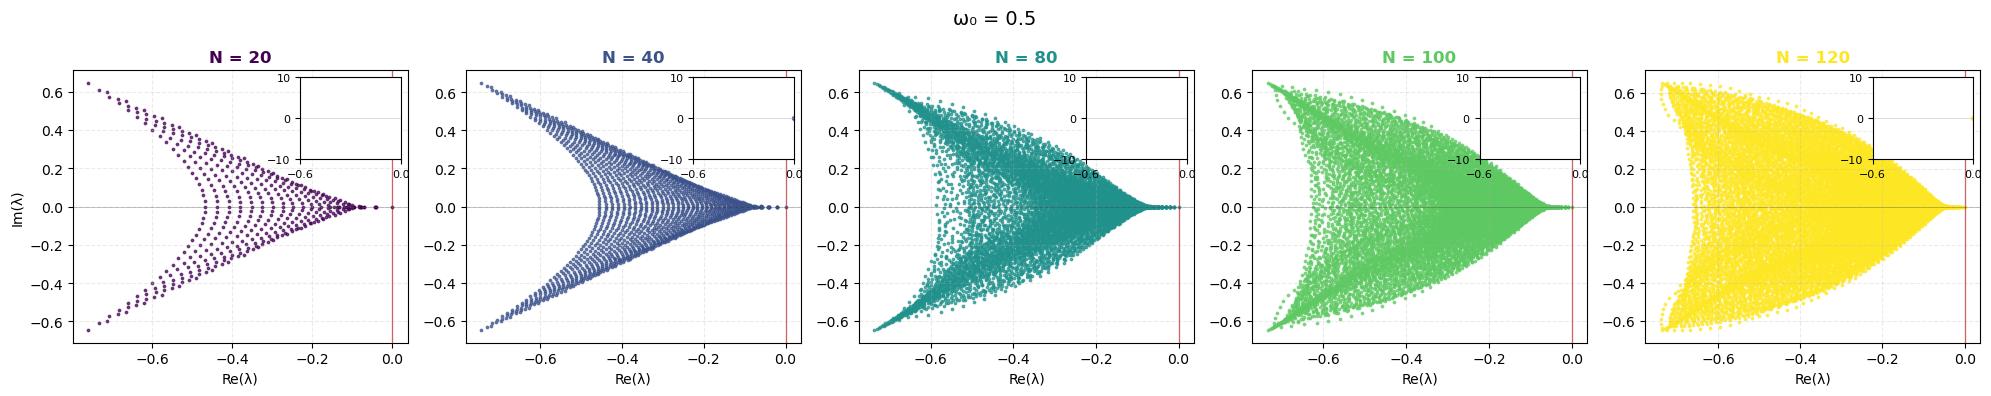

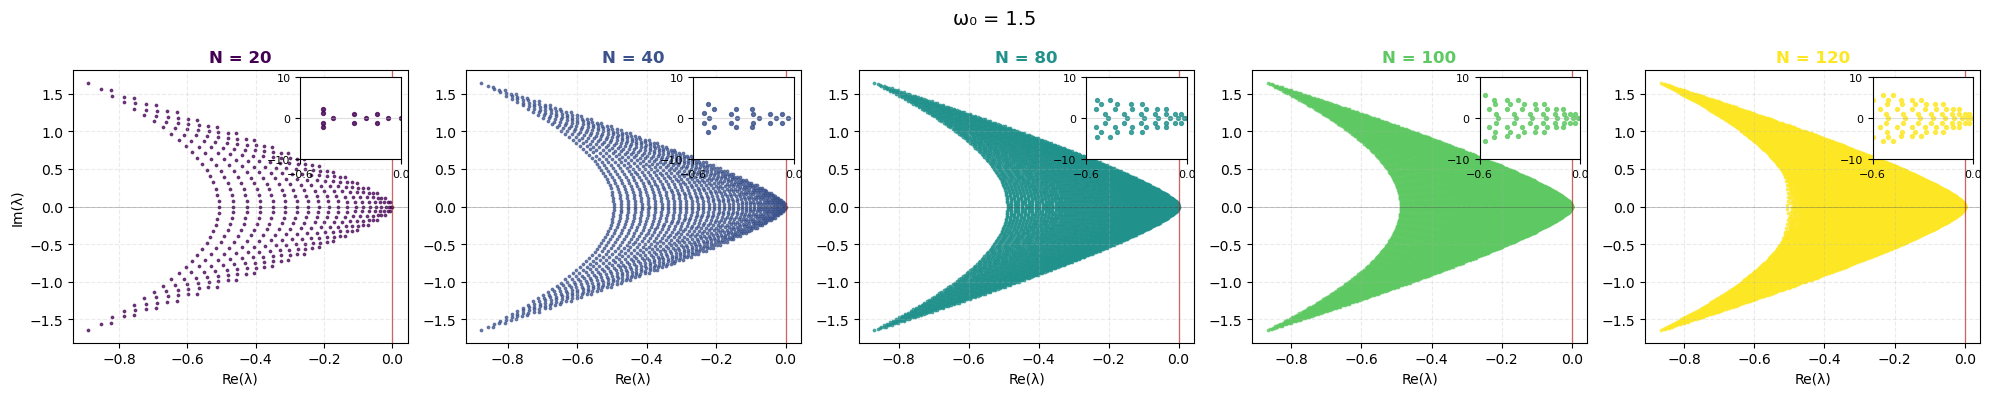

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
from collections import defaultdict

# --- Reorganizar: omega_0 -> { Nb -> eigs } ---
data = defaultdict(dict)
for (Nb, kappa, omega_0), eigs in eigenvalues.items():
    data[omega_0][Nb] = eigs  # kappa es siempre 1, no lo usamos para agrupar

Nbs_unicos = sorted({Nb for (Nb, _, _) in eigenvalues.keys()})
N_vals = len(Nbs_unicos)

# --- Una figura por cada omega_0 ---
for idx, (omega_0, por_Nb) in enumerate(sorted(data.items())):
    fig, axes = plt.subplots(1, N_vals, figsize=(20, 4), squeeze=False)
    axes = axes[0]
    fig.suptitle(f"ω₀ = {omega_0}", fontsize=14)

    colors = plt.cm.viridis(np.linspace(0, 1, len(Nbs_unicos)))

    for i, N in enumerate(Nbs_unicos):
        ax = axes[i]
        color = colors[i]

        # --- Scatter principal ---
        if N in por_Nb:
            eigs = por_Nb[N]
            kappa = 1  # constante, pero lo dejamos explícito por claridad
            X = np.real(eigs) / N * kappa
            Y = np.imag(eigs) / N * kappa
            ax.scatter(X, Y, s=3, color=color, alpha=0.7, rasterized=True)

        ax.set_title(f'N = {N}', fontsize=12, color=color, fontweight='bold')
        ax.set_xlabel('Re(λ)', fontsize=10)
        if i == 0:
            ax.set_ylabel('Im(λ)', fontsize=10)

        ax.axhline(0, color='black', lw=0.5, alpha=0.3)
        ax.axvline(0, color='black', lw=0.5, alpha=0.3)
        ax.grid(True, alpha=0.25, linestyle='--')

        # --- Inset (zoom) ---
        axins = inset_axes(ax, width="30%", height="30%", loc='upper right')

        if N in por_Nb:
            eigs = por_Nb[N]
            X = np.real(eigs) / kappa
            Y = np.imag(eigs) / kappa
            mask = (X > -0.6) & (X < 0) & (Y > -10) & (Y < 10)
            if np.any(mask):
                axins.scatter(X[mask], Y[mask], s=8, color=color, alpha=0.8)

        x1, x2 = -0.6, 0
        y1, y2 = -10, 10
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1, y2)
        axins.grid(0.5, alpha=0.4)
        axins.tick_params(axis='both', labelsize=8)
        axins.set_xticks([x1, x2])
        axins.set_yticks([y1, 0, y2])

        # Indicador de zona de zoom
        rect = Rectangle((x1*N, y1*N), x2*N - x1*N, y2*N - y1*N,
                         linewidth=1, edgecolor='red',
                         facecolor='none', alpha=0.5)
        ax.add_patch(rect)

    fig.tight_layout()
    plt.show()

## Escalado de los eigenvalores reales

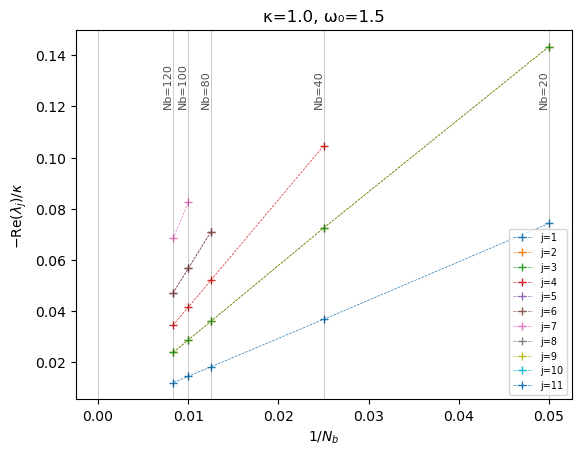

In [19]:
# --- Selecciona la fase (kappa, omega_0) a analizar ---
kappa_sel = kappa_list[0]
omega_0_sel = omega_0_list[2]

eigenvalues_phase = {Nb: eigs for (Nb, kappa, omega_0), eigs in eigenvalues.items()
                      if kappa == kappa_sel and omega_0 == omega_0_sel}

real_scaling = {}
eps = 0.5
k = kappa_sel

for Nb, eigs in eigenvalues_phase.items():

    # Ordenarlos de mayor a menor,
    # La funcion argsort devuelve un array con las posiciones de menor a mayor entonces lo invertimos con [::-1]
    eigs_sorted = eigs[np.argsort(np.real(eigs))[::-1]]

    selected = []

    # Aquí sec considera el criterio que hace el paper j^2/Nb < epsilon, en este codigo eps = 0.5
    for j, eig in enumerate(eigs_sorted):

        nu = j**2 / Nb

        if nu < eps:
            selected.append((j, np.real(eig)/k))

    real_scaling[Nb] = selected

max_j = 12

for j in range(1, max_j):

    x = []
    y = []

    for Nb in sorted(real_scaling.keys()):    # Este loop corre por 20,40,80,...,200

        data = real_scaling[Nb]

        if j < len(data):

            x.append(1/Nb)
            y.append(-data[j][1]) # -Re(lambda)
    plt.plot(x, y, '+--', label=f'j={j}', lw=0.5)
plt.xlabel(r'$1/N_b$')
plt.ylabel(r'$-\mathrm{Re}(\lambda_j)/\kappa$')
plt.axvline(0, lw=0.5, c='black', alpha=0.3)

for Nb in sorted(real_scaling.keys()):
    plt.axvline(1/Nb, lw=0.5, c='black', alpha=0.3)
    ymin, ymax = plt.ylim()

    plt.text(
        1/Nb,
        ymax*0.8,
        f'Nb={Nb}',
        rotation=90,
        fontsize=8,
        ha='right',
        alpha=0.7
    )
plt.title(f'κ={kappa_sel}, ω₀={omega_0_sel}')
plt.legend(fontsize='x-small', loc = 'lower right')
plt.show()


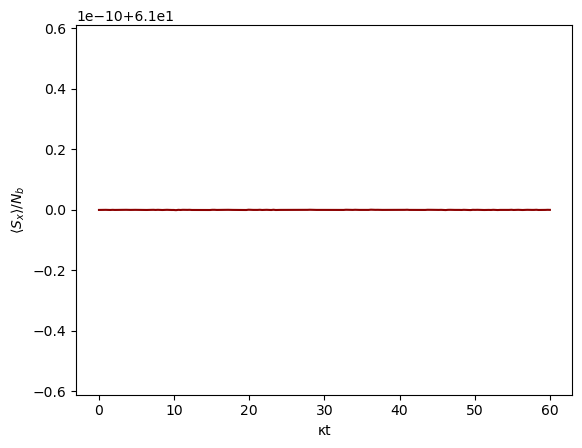

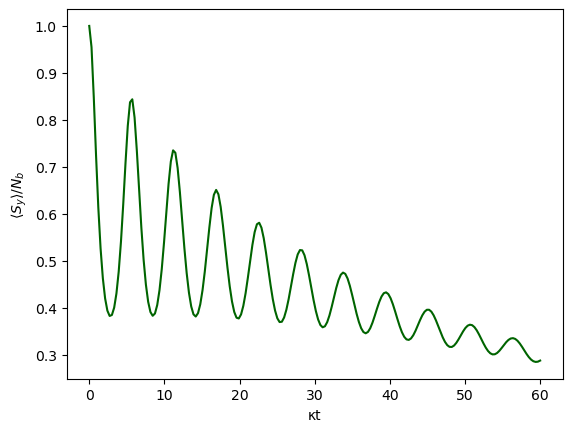

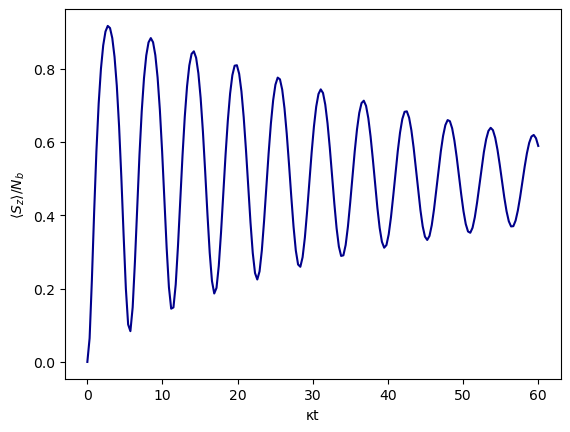

In [26]:
# --- Selecciona la combinación (Nb, kappa, omega_0) a graficar ---
Nb_plot = 120
key_plot = (Nb_plot, kappa_sel, omega_0_sel)

S = Nb_plot / 2
evo = results[key_plot]
t = evo.times

# exp_ops = [Sx, Sy, Sz], en ese orden
Sx_t = evo.expect[0]
Sy_t = evo.expect[1]
Sz_t = evo.expect[2]

plt.plot(int(kappa_sel)*t, Sx_t/S, c='darkred')
plt.xlabel("κt")
plt.ylabel(r"$\langle S_x\rangle / N_b$")
plt.show()

plt.plot(int(kappa_sel)*t, Sy_t/S, c='darkgreen')
plt.xlabel("κt")
plt.ylabel(r"$\langle S_y\rangle / N_b$")
plt.show()

plt.plot(int(kappa_sel)*t, Sz_t/S, c='darkblue')
plt.xlabel("κt")
plt.ylabel(r"$\langle S_z\rangle / N_b$")
plt.show()
